# Whorlmap Algorithm — Explanation Panels

Panels A–D illustrating how the whorl cell encodes a bootstrap distribution.

## Imports

In [61]:
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import seaborn as sns
from scipy.stats import gaussian_kde, norm
import dabest
from dabest.multi import combine, whorlmap

plt.rcParams.update({'font.size': 9, 'axes.titlesize': 10})

IMAGES = pathlib.Path('images')
IMAGES.mkdir(exist_ok=True)


## Helper functions

Exact reimplementation of dabest's internal spiral logic, so each panel can be built
without importing private functions.

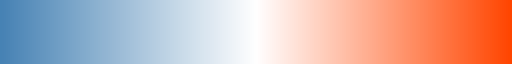

In [ ]:
def _spiralize(fill, m, n):
    """Outside-in rectangular spiral: top row right, right col down,
    bottom row left, left col up, then shrinks inward."""
    i = 0; j = 0; k = 0
    array = np.zeros((m, n))
    while m > 0 and k < len(fill):
        jj = j; ii = i
        for j in range(j, n):
            if k >= len(fill): break
            array[i, j] = fill[k]; k += 1
        for i in range(ii + 1, m):
            if k >= len(fill): break
            array[i, j] = fill[k]; k += 1
        for j in range(n - 2, jj - 1, -1):
            if k >= len(fill): break
            array[i, j] = fill[k]; k += 1
        for i in range(m - 2, ii, -1):
            if k >= len(fill): break
            array[i, j] = fill[k]; k += 1
        m -= 1; n -= 1; j += 1
    return array


def make_cell(bootstrap, n=21, chop_tail=2.5, reverse_neg=True):
    """Full pipeline: raw bootstrap array -> n x n spiral cell."""
    bs = sorted(bootstrap)
    chop = int(np.ceil(len(bs) * chop_tail / 100))
    if chop > 0:
        bs = bs[chop:-chop]
    ranks = np.linspace(0, len(bs), n * n, dtype=int)
    ranks[0] = 1
    if sum(v > 0 for v in bs) < len(bs) / 2 and reverse_neg:
        bs = bs[::-1]
    fill = [bs[r - 1] for r in ranks]
    return _spiralize(fill, n, n)

from matplotlib.colors import LinearSegmentedColormap


gradient_colors1 =  ["#05a84c", "#FFFFFF",  "#7e06be"]
gwp = LinearSegmentedColormap.from_list("gwp", gradient_colors1, N=256)
gradient_colors2 =  ["steelblue","white",  "orangered"]
steelwhiteorangered = LinearSegmentedColormap.from_list("steelwhiteorangered", gradient_colors2, N=256)

# Diverging colormap and norm — swap CMAP here to try a different palette
CMAP  = steelwhiteorangered
DNORM = TwoSlopeNorm(vcenter=0, vmin=-3.5, vmax=3.5)


## Panel A — From bootstrap distribution to whorl cell

Showing explicitly how quantile rank encodes spatial position.  
**Left**: 7×7 whorl cell coloured by effect size (RdBu_r); each ring is outlined in a
distinct position colour.  
**Right**: Bootstrap distribution as a histogram (bars coloured by effect size);
horizontal brackets — in the same position colours — show which quantile band maps to
which ring.


In [ ]:
matplotlib.use('Agg')
import pathlib, pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase
import dabest
from dabest.multi import combine

plt.rcParams.update({'font.size': 9, 'axes.titlesize': 10})
IMAGES = pathlib.Path('images')

# steelblue → white (at midpoint 0.5) → orange → crimson
# White MUST be at position 0.5 so Normalize(-bound, bound) places white at value 0
CMAP_SWOR = LinearSegmentedColormap.from_list(
    'steelwhiteorangered',
    [(0.00, (70/255, 130/255, 180/255)),
     (0.50, (1.0,   1.0,   1.0  )),
     (0.75, (1.0,   0.55,  0.0  )),
     (1.00, (0.86,  0.08,  0.24 ))],
    N=256
)

def _spiralize(fill, m, n):
    i=0; j=0; k=0; array=np.zeros((m,n))
    while m>0 and k<len(fill):
        jj=j; ii=i
        for j in range(j,n):
            if k>=len(fill): break
            array[i,j]=fill[k]; k+=1
        for i in range(ii+1,m):
            if k>=len(fill): break
            array[i,j]=fill[k]; k+=1
        for j in range(n-2,jj-1,-1):
            if k>=len(fill): break
            array[i,j]=fill[k]; k+=1
        for i in range(m-2,ii,-1):
            if k>=len(fill): break
            array[i,j]=fill[k]; k+=1
        m-=1; n-=1; j+=1
    return array

def _spiral_path(n):
    path = []
    top, bot, lft, rgt = 0, n-1, 0, n-1
    while top <= bot and lft <= rgt:
        for c in range(lft, rgt+1): path.append((top, c))
        top += 1
        for r in range(top, bot+1): path.append((r, rgt))
        rgt -= 1
        if top <= bot:
            for c in range(rgt, lft-1, -1): path.append((bot, c))
            bot -= 1
        if lft <= rgt:
            for r in range(bot, top-1, -1): path.append((r, lft))
            lft += 1
    return path

def _ring_structure(n):
    rings, pos, k = [], 0, 0
    while True:
        sz = n - 2*k
        if sz <= 0: break
        nc = 1 if sz == 1 else 4*(sz-1)
        rings.append({'k': k, 'start': pos, 'end': pos+nc, 'sz': sz})
        pos += nc; k += 1
        if sz == 1: break
    return rings

# Bootstrap
n = 7; N = n*n
_rng    = np.random.default_rng(42)
noise_a = _rng.normal(0, 3., 20); noise_b = _rng.normal(0, 3., 20)
group_a = noise_a - noise_a.mean(); group_b = noise_b - noise_b.mean() + 0.5
_df_a   = pd.DataFrame({'group': ['A']*20+['B']*20,
                         'value': np.concatenate([group_a, group_b])})
_dobj_a = dabest.load(_df_a, x='group', y='value', idx=('A', 'B'))
_multi_a = combine([[_dobj_a]], ['gene'], row_labels=['region'], effect_size='mean_diff')
bs_raw  = sorted(_multi_a.bootstraps[0])
chop    = int(np.ceil(len(bs_raw)*0.025)); bs_c = bs_raw[chop:-chop]
ranks   = np.linspace(0, len(bs_c), N, dtype=int); ranks[0] = 1
fv      = np.array([bs_c[r-1] for r in ranks])
if sum(v>0 for v in bs_c) < len(bs_c)/2: fv = fv[::-1]

XLIM  = (-3.5, 3.5)
rings = _ring_structure(n)

fv_sorted  = np.clip(np.sort(fv), *XLIM)
cell_vals  = _spiralize(fv.tolist(), n, n)

# Symmetric value-based norm — same for panel AND colorbar so colours match exactly
bound      = max(2.0, np.ceil(max(abs(fv_sorted[0]), abs(fv_sorted[-1])) * 2) / 2)
VALUE_NORM = Normalize(vmin=-bound, vmax=bound)

spiral_pos = _spiral_path(n)

# Figure
fig = plt.figure(figsize=(11, 5.4))
ax_cell = fig.add_axes([0.03, 0.18, 0.32, 0.68])
ax_cbar = fig.add_axes([0.03, 0.08, 0.32, 0.05])
ax_hist = fig.add_axes([0.43, 0.12, 0.54, 0.74])

# Left: whorl cell coloured by effect size value (same norm as colorbar)
ax_cell.imshow(cell_vals, cmap=CMAP_SWOR, norm=VALUE_NORM,
               origin='upper', interpolation='nearest', aspect='equal')

def _ring_arrows(ax, ring_k, sz, avg_val):
    mid = ring_k + sz // 2
    bg  = CMAP_SWOR(VALUE_NORM(avg_val))
    col = 'w' if (0.299*bg[0] + 0.587*bg[1] + 0.114*bg[2]) < 0.52 else 'k'
    ap  = dict(arrowstyle='->', color=col, lw=1.0, mutation_scale=9)
    d   = 0.25  # shift outward from pixel centre by this fraction of a cell
    ax.annotate('', xy=(mid+0.6, ring_k-d),         xytext=(mid-0.6, ring_k-d),         arrowprops=ap, zorder=8, annotation_clip=False)
    ax.annotate('', xy=(ring_k+sz-1+d, mid+0.6),    xytext=(ring_k+sz-1+d, mid-0.6),    arrowprops=ap, zorder=8, annotation_clip=False)
    ax.annotate('', xy=(mid-0.6, ring_k+sz-1+d),    xytext=(mid+0.6, ring_k+sz-1+d),    arrowprops=ap, zorder=8, annotation_clip=False)
    ax.annotate('', xy=(ring_k-d, mid-0.6),             xytext=(ring_k-d, mid+0.6),             arrowprops=ap, zorder=8, annotation_clip=False)

for ring in rings[:-1]:
    avg_val = float(np.mean(fv_sorted[ring['start']:ring['end']]))
    _ring_arrows(ax_cell, ring['k'], ring['sz'], avg_val)

# Annotate every pixel: quantile rank + effect size value (luminance from VALUE_NORM)
for k, (r, c) in enumerate(spiral_pos):
    val = float(fv[k])
    bg  = CMAP_SWOR(VALUE_NORM(val))
    lum = 0.299*bg[0] + 0.587*bg[1] + 0.114*bg[2]
    tc  = 'w' if lum < 0.52 else 'k'
    ax_cell.text(c, r, f'q{k}\n{val:.1f}',
                 ha='center', va='center', fontsize=4.5, color=tc,
                 zorder=10, linespacing=1.1, multialignment='center')

ax_cell.set_xlim(-0.5, n-0.5); ax_cell.set_ylim(n-0.5, -0.5)
ax_cell.axis('off')
ax_cell.set_title('7×7 whorl cell — outside-in spiral fill\n(pixel colour = effect size)', fontsize=9)

# Colorbar: same VALUE_NORM — colours identical between panel and bar
cb = ColorbarBase(ax_cbar, cmap=CMAP_SWOR, norm=VALUE_NORM, orientation='horizontal')
cb_ticks = np.arange(-bound, bound + 0.01, 0.5)
cb.set_ticks(cb_ticks)
cb.set_ticklabels([f'{t:g}' for t in cb_ticks])
cb.ax.tick_params(labelsize=7.5)
cb.set_label('Effect size (bootstrap mean difference)', fontsize=8)

# Right: stacked quantile histogram (value-coloured segments, matching panel + colorbar)
BIN_W = 0.20
bins  = np.arange(XLIM[0], XLIM[1]+BIN_W, BIN_W)
counts, _ = np.histogram(np.clip(bs_c, *XLIM), bins=bins, density=True)

seg_bounds = np.empty(N+1)
seg_bounds[0] = XLIM[0]; seg_bounds[-1] = XLIM[1]
for k in range(1, N):
    seg_bounds[k] = (fv_sorted[k-1] + fv_sorted[k]) / 2.0
seg_cols = [CMAP_SWOR(VALUE_NORM(float(v))) for v in fv_sorted]

best_piece = {}  # k -> (x_center, y_bottom, h)

for lo, hi, ht in zip(bins[:-1], bins[1:], counts):
    if ht == 0: continue
    y_bot = 0.0
    for k in range(N):
        overlap = max(0., min(hi, seg_bounds[k+1]) - max(lo, seg_bounds[k]))
        if overlap <= 0: continue
        h = ht * overlap / (hi - lo)
        ax_hist.bar(lo, h, width=hi-lo, bottom=y_bot,
                    align='edge', color=seg_cols[k], edgecolor='none')
        if k not in best_piece or h > best_piece[k][2]:
            best_piece[k] = (lo + (hi - lo) / 2, y_bot, h)
        y_bot += h

for k, (xc, yb, h) in best_piece.items():
    if h < counts.max() * 0.005: continue
    val = float(fv_sorted[k])
    col = CMAP_SWOR(VALUE_NORM(val))
    lum = 0.299*col[0] + 0.587*col[1] + 0.114*col[2]
    tc  = 'w' if lum < 0.52 else 'k'
    ax_hist.text(xc, yb + h/2, f'q{k}\n{val:.1f}',
                 ha='center', va='center', fontsize=3.5, color=tc,
                 zorder=11, linespacing=1.0, multialignment='center')

margin = (fv_sorted[-1] - fv_sorted[0]) * 0.08
ax_hist.set_xlim(fv_sorted[0] - margin, fv_sorted[-1] + margin)
ax_hist.set_ylim(0, counts.max()*1.03)
ax_hist.spines['left'].set_visible(False)
ax_hist.spines['right'].set_visible(False); ax_hist.spines['top'].set_visible(False)
ax_hist.set_yticks([]); ax_hist.tick_params(labelsize=8)
ax_hist.set_xlabel('Bootstrap mean difference', fontsize=9)
ax_hist.set_title('Bootstrap distribution, segmented by quantile rank\n'
                  '(bar colours match spiral position on left)', fontsize=9)

fig.suptitle('A   From bootstrap distribution to whorl cell: '
             'quantile rank encodes spatial position',
             fontsize=11, fontweight='bold', x=0.02, ha='left', y=0.99)

fig.savefig(IMAGES/'panel_a.svg', bbox_inches='tight')
fig.savefig(IMAGES/'panel_a.png', dpi=600, bbox_inches='tight')
print("Saved panel_a.svg / panel_a.png")

## ~~Panel B~~ — retired (merged into Panel A)


In [ ]:
# Panel B retired — content merged into Panel A


## Panel C — Cell taxonomy

Five canonical distribution shapes and the whorl cells they produce.
All cells share the same colour scale (vlag, ±3.5).

/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:523: UserWarning: The lower limit of the BCa interval of baseline curve cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="lower"), stacklevel=0)
/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:527: UserWarning: The upper limit of the BCa interval of baseline curve cannot be computed. It is set to the effect size itself. All bootstrap values were likely all the same.
  warnings.warn(err_temp.substitute(lim_type="upper"), stacklevel=0)


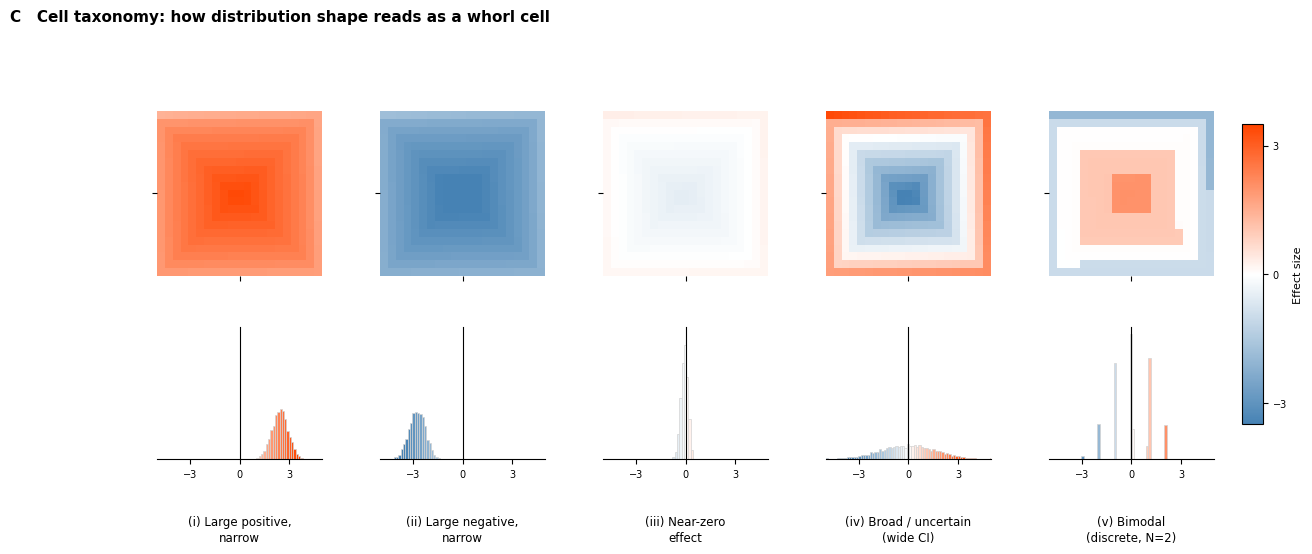

In [123]:
def _make_1x1_multi(group_a, group_b):
    """Wrap two sample arrays into a 1x1 MultiContrast for whorlmap."""
    df = pd.DataFrame({
        'group': ['A'] * len(group_a) + ['B'] * len(group_b),
        'value': np.concatenate([group_a, group_b])
    })
    dobj = dabest.load(df, x='group', y='value', idx=('A', 'B'))
    return combine([[dobj]], [''], row_labels=[''], effect_size='mean_diff')


_rng = np.random.default_rng(1234)
_ga1 = _rng.normal(0, 1.5, 22);  _gb1 = _rng.normal( 3.0, 1.5, 22)
_ga2 = _rng.normal(0, 1.5, 22);  _gb2 = _rng.normal(-3.0, 1.5, 22)
_ga3 = _rng.normal(0, 0.4, 5); _gb3 = _rng.normal( 0.05, 0.4, 5)
_ga4 = _rng.normal(0, 0.5,  15); _gb4 = _rng.normal( 0.3,  6.0,  15)
_ga5 = np.array([0, 0, 0, 0, 0,])       # N=2 → 3 discrete bootstrap values: honest representation
_gb5 = np.array([2.1, 2,  2.05,-3,  -3.05  ])

scenarios = [
    ('(i) Large positive,\nnarrow',      _make_1x1_multi(_ga1, _gb1)),
    ('(ii) Large negative,\nnarrow',      _make_1x1_multi(_ga2, _gb2)),
    ('(iii) Near-zero\neffect',           _make_1x1_multi(_ga3, _gb3)),
    ('(iv) Broad / uncertain\n(wide CI)', _make_1x1_multi(_ga4, _gb4)),
    ('(v) Bimodal\n(discrete, N=2)',      _make_1x1_multi(_ga5, _gb5)),
]

# Histogram parameters: fixed bin width = heatmap colour range, shared y-max
XLIM  = (-5, 5)
BIN_W = 0.14
BINS  = np.arange(XLIM[0], XLIM[1] + BIN_W, BIN_W)
BINCX = 0.5 * (BINS[:-1] + BINS[1:])   # bin centres for colouring

hists = []
for _, multi in scenarios:
    bs = np.clip(multi.bootstraps[0], *XLIM)
    counts, _ = np.histogram(bs, bins=BINS, density=True)
    hists.append(counts)
ymax = max(h.max() for h in hists)*1.05

fig, axes = plt.subplots(
    2, 5, figsize=(14, 5),
    gridspec_kw={'hspace': 0.08, 'wspace': 0.35, 'height_ratios': [1.8, 1]}
)

for j, ((label, multi), counts) in enumerate(zip(scenarios, hists)):
    multi.whorlmap(
        n=21, chop_tail=2.5, cmap=CMAP, vmin=-3.5, vmax=3.5,
        ax=axes[0, j],
        heatmap_kwargs={'cbar': False},
        plot_kwargs={'xticklabels': [''], 'yticklabels': ['']},
    )
    axes[0, j].set_aspect('equal')

    ax = axes[1, j]
    cols = CMAP(DNORM(BINCX))
    for lo, hi, ht, c in zip(BINS[:-1], BINS[1:], counts, cols):
        ax.bar(lo, ht, width=hi - lo, align='edge', color=c,
               edgecolor='lightgray', linewidth=.5)
    ax.set_xlim(*XLIM)
    ax.set_ylim(0, ymax)
    ax.spines['left'].set_position('zero')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_yticks([])
    ax.set_xticks([-3, 0, 3])
    ax.tick_params(labelsize=7)
    ax.text(0.5, -0.42, label, transform=ax.transAxes,
            ha='center', fontsize=8.5, va='top', linespacing=1.3)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.18, 0.015, 0.60])
sm = ScalarMappable(cmap=CMAP, norm=DNORM)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Effect size', fontsize=8)
cbar.set_ticks([-3, 0, 3])
cbar.ax.tick_params(labelsize=7)

plt.suptitle(
    'C   Cell taxonomy: how distribution shape reads as a whorl cell',
    fontsize=11, fontweight='bold', x=0.02, ha='left', y=1.01
)
fig.savefig(IMAGES / 'panel_c.svg', bbox_inches='tight')
fig.savefig(IMAGES / 'panel_c.png', dpi=600, bbox_inches='tight')
plt.show()


In [115]:
scenarios[4][1].bootstraps

[array([-0.00833333,  0.        , -3.00833333, ..., -2.00833333,
         0.        , -0.99166667])]

## Panel D — Real whorlmap vs. scalar heatmap

Simulated transcriptomics data: 6 drugs × 8 transcripts, delta-delta design.
The whorlmap (left) preserves the full bootstrap distribution per cell;
the scalar mean heatmap (right) collapses each to a single number.

In [124]:
def create_delta_dataset(
    N=50, seed=9999,
    second_quarter_adjustment=3,
    third_quarter_adjustment=-0.5,
    fourth_quarter_adjustment=-3,
    scale4=1, initial_loc=10
):
    np.random.seed(seed)
    y = norm.rvs(loc=initial_loc, scale=0.4, size=N * 4)
    y[N:2*N]   = norm.rvs(loc=initial_loc + second_quarter_adjustment, scale=1,      size=N)
    y[2*N:3*N] = norm.rvs(loc=initial_loc + third_quarter_adjustment,  scale=0.4,    size=N)
    y[3*N:4*N] = norm.rvs(loc=initial_loc + fourth_quarter_adjustment, scale=scale4, size=N)
    return pd.DataFrame({
        'ID':               list(range(N * 2)) * 2,
        'Genotype':         np.repeat(['W', 'M', 'W', 'M'], N).tolist(),
        'Treatment':        np.repeat(['Placebo', 'Drug'], N * 2).tolist(),
        'Transcript Level': y,
    })


labels_2d     = [f'Transcript {i}' for i in range(1, 9)]
row_labels_2d = ['Drug A', 'Drug B', 'Drug C', 'Drug D', 'Drug E', 'Drug F']

drug_effect = [
    [ .9,  2.0,  2.0,  .5,  1.2,  1.0,  3.0, 2.0],
    [ .1,  -.3,   .1, -.3, -2.0,  1.2,  1.0,  .1],
    [4.0,  4.0,  1.0, 5.0,  1.0,  3.0,  6.5,  .5],
    [6.0,  2.0,  2.0, 4.0,  1.4,  -.5,  -.5, 1.1],
    [ .1,  -.3,   .1, -.3, -2.0,  1.2,  1.0,  .1],
    [-.3, -1.0,  2.0, 7.0,  1.0,  -.5,  4.0, 1.0],
]
drug_scale = [
    [ 5, 10,  1,  5,  1,  2,  1, 1],
    [ 7,  .2, 8,  3,  1,  4,  7, 1],
    [15,  3,  1,  2,  1,  1, 11, 1],
    [ 8,  .1, 1,  5,  1,  6,  1, 1],
    [ 9, 10,  7, 12,  4,  2, 14, 10],
    [ 4,  3,  1,  4,  1,  4,  4,  1],
]
seeds = [1, 1000, 20, 9999, 1000, 5320]

dabest_objects_2d = [[None] * 8 for _ in range(6)]
for i in range(6):
    for j in range(8):
        df = create_delta_dataset(
            seed=seeds[i],
            fourth_quarter_adjustment=drug_effect[i][j],
            scale4=drug_scale[i][j],
            initial_loc=20
        )
        dabest_objects_2d[i][j] = dabest.load(
            data=df,
            x=['Genotype', 'Genotype'],
            y='Transcript Level',
            delta2=True,
            experiment='Treatment'
        )

multi_2d = combine(dabest_objects_2d, labels_2d,
                   row_labels=row_labels_2d, effect_size='mean_diff')
print(multi_2d)

MultiContrast(2D: 6x8, effect_size='mean_diff', contrast_type='delta2')


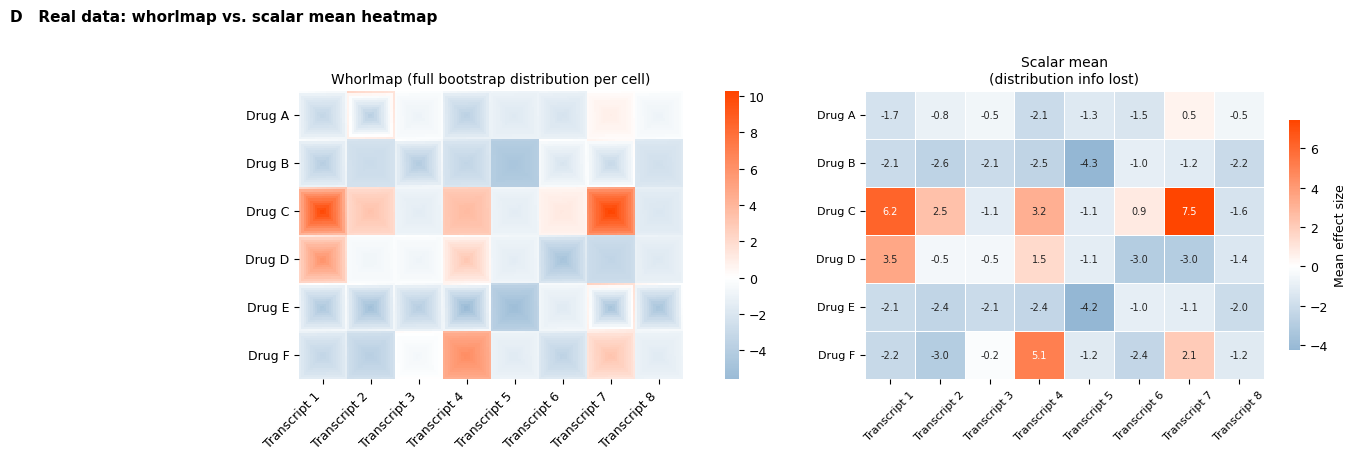

In [126]:
fig, (ax_whorl, ax_scalar) = plt.subplots(
    1, 2, figsize=(14, 4.5),
    gridspec_kw={'width_ratios': [3, 1.8]}
)

_, mean_df = multi_2d.whorlmap(
    cmap=CMAP, chop_tail=2.5,
    title='Whorlmap (full bootstrap distribution per cell)',
    ax=ax_whorl
)
ax_whorl.set_aspect('equal')

sns.heatmap(
    mean_df, ax=ax_scalar,
    cmap=CMAP, center=0,
    annot=True, fmt='.1f',
    linewidths=0.5, linecolor='white',
    annot_kws={'fontsize': 7},
    cbar_kws={'label': 'Mean effect size', 'shrink': 0.8}
)
ax_scalar.set_title('Scalar mean\n(distribution info lost)', fontsize=10)
ax_scalar.tick_params(axis='x', rotation=45, labelsize=8)
ax_scalar.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle(
    'D   Real data: whorlmap vs. scalar mean heatmap',
    fontsize=11, fontweight='bold', x=0.02, ha='left', y=1.01
)
plt.tight_layout()
fig.savefig(IMAGES / 'panel_d_sim.svg', bbox_inches='tight')
fig.savefig(IMAGES / 'panel_d_sim.png', dpi=600, bbox_inches='tight')
plt.show()


## Panel D — GTEx real data: sex-biased gene expression across human brain regions

Female − Male mean difference (log₂TPM+1), 13 brain regions × selected genes.  
Left columns: sex-chromosome and hormone-receptor anchors (large known effects).  
Right columns: 20 genes sampled for distribution-shape variety.

In [127]:
import os, gzip, pathlib, urllib.request
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR = pathlib.Path("gtex_data")
DATA_DIR.mkdir(exist_ok=True)

TPM_GZ    = DATA_DIR / "GTEx_gene_tpm.gct.gz"
ATTR_FILE = DATA_DIR / "GTEx_SampleAttributes.txt"
PHENO_FILE= DATA_DIR / "GTEx_SubjectPhenotypes.txt"

GTEX_BASE      = "https://storage.googleapis.com/adult-gtex"
GTEX_TPM_URL   = (f"{GTEX_BASE}/bulk-gex/v8/rna-seq/"
                   "GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz")
GTEX_ATTR_URL  = (f"{GTEX_BASE}/annotations/v8/metadata-files/"
                   "GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt")
GTEX_PHENO_URL = (f"{GTEX_BASE}/annotations/v8/metadata-files/"
                   "GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt")

# ── Brain regions ──────────────────────────────────────────────────────────────
BRAIN_REGIONS = {
    "Hypothalamus":      "Brain - Hypothalamus",
    "Amygdala":          "Brain - Amygdala",
    "Hippocampus":       "Brain - Hippocampus",
    "Ant. Cing. Ctx":    "Brain - Anterior cingulate cortex (BA24)",
    "Frontal Cortex":    "Brain - Frontal Cortex (BA9)",
    "Cortex":            "Brain - Cortex",
    "Caudate":           "Brain - Caudate (basal ganglia)",
    "Putamen":           "Brain - Putamen (basal ganglia)",
    "Nucleus Accumbens": "Brain - Nucleus accumbens (basal ganglia)",
    "Cerebellum":        "Brain - Cerebellum",
    "Cerebellar Hemi.":  "Brain - Cerebellar Hemisphere",
    "Substantia Nigra":  "Brain - Substantia nigra",
    "Spinal Cord":       "Brain - Spinal cord (cervical c-1)",
}

# ── Candidate genes for survey (~150) ──────────────────────────────────────────
CANDIDATE_GENES = [
    # Sex-chromosome anchors
    "XIST", "RPS4Y1", "DDX3Y", "KDM5D", "USP9Y", "EIF1AY", "KDM6A", "KDM5C", "MECP2",
    # Hormone receptors
    "ESR1", "ESR2", "AR", "PGR", "CYP19A1", "NR3C1", "NR3C2", "FKBP5",
    # Dopamine
    "DRD1", "DRD2", "DRD3", "DRD4", "DRD5", "SLC6A3", "TH", "DDC", "COMT", "MAOB",
    # Serotonin
    "HTR1A", "HTR1B", "HTR2A", "HTR2B", "HTR2C", "HTR3A", "SLC6A4", "TPH2", "MAOA",
    # GABA
    "GABRA1", "GABRA2", "GABRA3", "GABRA4", "GABRA5",
    "GABRB1", "GABRB2", "GABRB3", "GABRG2", "GAD1", "GAD2",
    # Glutamate
    "GRIA1", "GRIA2", "GRIA3", "GRIN1", "GRIN2A", "GRIN2B", "GRM1", "GRM5",
    # Acetylcholine
    "CHRM1", "CHRM2", "CHRNA4", "CHRNA7",
    # Norepinephrine
    "ADRA1A", "ADRA2A", "SLC6A2",
    # Opioid
    "OPRM1", "OPRD1", "OPRK1", "PENK", "PDYN",
    # Cannabinoid
    "CNR1",
    # Neuropeptides
    "NPY", "VIP", "SST", "CRH", "CRHR1", "CRHR2", "NTS", "CARTPT", "POMC", "AGRP",
    "OXTR", "AVPR1A", "AVPR1B", "KISS1", "KISS1R",
    # Neurotrophins
    "BDNF", "NTRK2", "NGF", "NTF3",
    # Synaptic
    "NRXN1", "NRXN2", "NRXN3", "NLGN1", "NLGN3", "SHANK2", "SHANK3",
    "SYP", "SYN1", "SNAP25",
    # Glia / myelin
    "MBP", "PLP1", "GFAP", "AIF1", "S100B", "MOG",
    # Inflammation
    "IL6", "TNF", "IL1B", "TGFB1",
    # Clock genes
    "CLOCK", "ARNTL", "PER1", "PER2", "CRY1", "CRY2",
    # Neurodegeneration
    "APP", "MAPT", "SNCA", "LRRK2", "APOE", "CLU",
    # Misc / X-linked
    "FMR1", "PTEN",
    # Housekeeping (expect neutral)
    "ACTB", "GAPDH", "RPL19", "UBB", "HPRT1", "B2M",
]

print(f"Brain regions : {len(BRAIN_REGIONS)}")
print(f"Candidate genes: {len(CANDIDATE_GENES)}")

Brain regions : 13
Candidate genes: 127


In [128]:
def _download(url, dest, label):
    if dest.exists():
        print(f"  cached  {dest}")
        return
    print(f"  downloading {label} ...", end=" ", flush=True)
    urllib.request.urlretrieve(url, dest)
    size_mb = dest.stat().st_size / 1e6
    print(f"done  ({size_mb:.0f} MB)")

_download(GTEX_PHENO_URL, PHENO_FILE, "subject phenotypes")
_download(GTEX_ATTR_URL,  ATTR_FILE,  "sample attributes")
_download(GTEX_TPM_URL,   TPM_GZ,     "gene TPM matrix (~2 GB — takes several minutes)")

  cached  gtex_data/GTEx_SubjectPhenotypes.txt
  cached  gtex_data/GTEx_SampleAttributes.txt
  cached  gtex_data/GTEx_gene_tpm.gct.gz


In [129]:
# Build sample → (region_label, sex) lookup
pheno = pd.read_csv(PHENO_FILE, sep="\t")
sex_map = pheno.set_index("SUBJID")["SEX"].map({1: "Male", 2: "Female"})  # 1=M 2=F

attr = pd.read_csv(ATTR_FILE, sep="\t", usecols=["SAMPID", "SMTSD"])
attr["SUBJID"] = attr["SAMPID"].str.extract(r"(GTEX-[^-]+)")
attr["SEX"]    = attr["SUBJID"].map(sex_map)

target_tissues = set(BRAIN_REGIONS.values())
brain_attr = attr[attr["SMTSD"].isin(target_tissues) & attr["SEX"].notna()].copy()

# reverse lookup: GTEx tissue string → short label
region_rev = {v: k for k, v in BRAIN_REGIONS.items()}
brain_attr["region"] = brain_attr["SMTSD"].map(region_rev)

# final mapping: sample_id → (region, sex)
sample_meta = brain_attr.set_index("SAMPID")[["region", "SEX"]].rename(columns={"SEX": "sex"})

print("Brain samples per region:")
print(sample_meta.groupby(["region", "sex"]).size().unstack(fill_value=0).to_string())
print(f"\nTotal brain samples: {len(sample_meta)}")

Brain samples per region:
sex                Female  Male
region                         
Amygdala               55   122
Ant. Cing. Ctx         62   151
Caudate                83   208
Cerebellar Hemi.       74   189
Cerebellum             92   206
Cortex                 99   226
Frontal Cortex        111   314
Hippocampus            70   173
Hypothalamus           67   169
Nucleus Accumbens      77   200
Putamen                60   172
Spinal Cord            71   111
Substantia Nigra       48   116

Total brain samples: 3326


In [130]:
# Stream TPM file — extract only candidate genes for brain samples
# Output: gene_expr[gene][sample_id] = log2(TPM+1)

target_genes = set(CANDIDATE_GENES)
brain_samples = set(sample_meta.index)

gene_expr = {}   # {gene_name: {sample_id: float}}

print("Streaming TPM file ...", flush=True)
with gzip.open(TPM_GZ, "rt") as fh:
    fh.readline()           # #1.2
    fh.readline()           # nrow / ncol counts
    header = fh.readline().rstrip().split("\t")
    all_samples = header[2:]  # columns 0=ENSEMBL 1=gene_name 2..=samples

    # column indices for brain samples (offset by 2 for Name/Description cols)
    brain_col_idx = [i for i, s in enumerate(all_samples) if s in brain_samples]
    brain_col_names = [all_samples[i] for i in brain_col_idx]

    found = 0
    for line in fh:
        parts = line.rstrip().split("\t")
        gene = parts[1]
        if gene not in target_genes:
            continue
        tpm = np.array([float(parts[2 + i]) for i in brain_col_idx])
        gene_expr[gene] = dict(zip(brain_col_names, np.log2(tpm + 1)))
        found += 1
        print(f"  found {found}/{len(target_genes)}: {gene}", end="\r", flush=True)
        if found == len(target_genes):
            break

print(f"\nDone. Found {len(gene_expr)}/{len(target_genes)} genes.")
missing = target_genes - set(gene_expr)
if missing:
    print(f"Not in GTEx: {sorted(missing)}")

Streaming TPM file ...
  found 127/127: EIF1AY
Done. Found 127/127 genes.


In [131]:
# Bootstrap survey: for each (gene × region), compute F−M mean diff distribution
# Uses 2000 resamples for speed; final figure will use DABEST (5000)

RNG    = np.random.default_rng(42)
N_BOOT = 2000

def _bootstrap_mean_diff(f_vals, m_vals, n_boot=N_BOOT, rng=RNG):
    """Bootstrap distribution of mean(Female) − mean(Male)."""
    f, m = np.asarray(f_vals), np.asarray(m_vals)
    boots = (rng.choice(f, (n_boot, len(f)), replace=True).mean(axis=1)
           - rng.choice(m, (n_boot, len(m)), replace=True).mean(axis=1))
    return boots

def _bimodality_coef(x):
    """Sarle's bimodality coefficient. >0.555 suggests bimodality."""
    n  = len(x)
    g  = skew(x)
    k  = kurtosis(x, fisher=True)   # excess kurtosis
    bc = (g**2 + 1) / (k + 3 * (n - 1)**2 / ((n - 2) * (n - 3)))
    return bc

rows = []
# Store full bootstrap arrays for later use in final figure
boot_arrays = {}   # {(gene, region): array shape (N_BOOT,)}

for gene in CANDIDATE_GENES:
    if gene not in gene_expr:
        continue
    gd = gene_expr[gene]
    for region in BRAIN_REGIONS:
        mask = sample_meta["region"] == region
        sids = sample_meta.index[mask]
        f_sids = sids[sample_meta.loc[sids, "sex"] == "Female"]
        m_sids = sids[sample_meta.loc[sids, "sex"] == "Male"]
        f_vals = [gd[s] for s in f_sids if s in gd]
        m_vals = [gd[s] for s in m_sids if s in gd]
        if len(f_vals) < 5 or len(m_vals) < 5:
            continue
        boots = _bootstrap_mean_diff(f_vals, m_vals)
        boot_arrays[(gene, region)] = boots
        ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
        rows.append({
            "gene":       gene,
            "region":     region,
            "n_female":   len(f_vals),
            "n_male":     len(m_vals),
            "mean_md":    boots.mean(),
            "ci_lo":      ci_lo,
            "ci_hi":      ci_hi,
            "ci_width":   ci_hi - ci_lo,
            "bimod_coef": _bimodality_coef(boots),
            "skewness":   float(skew(boots)),
            "ci_crosses_zero": int(ci_lo < 0 < ci_hi),
        })

survey = pd.DataFrame(rows)
print(f"Survey complete: {len(survey)} (gene × region) pairs")
survey.head()

Survey complete: 1651 (gene × region) pairs


,gene,region,n_female,n_male,mean_md,ci_lo,ci_hi,ci_width,bimod_coef,skewness,ci_crosses_zero
0,XIST,Hypothalamus,55,147,3.093780,2.825190,3.368355,0.543165,0.331722,0.028471,0
1,XIST,Amygdala,45,107,2.680510,2.411403,2.935903,0.524500,0.344967,-0.114203,0
2,XIST,Hippocampus,54,143,2.794782,2.533156,3.053580,0.520424,0.313016,-0.102577,0
3,XIST,Ant. Cing. Ctx,48,128,2.711460,2.448480,2.974649,0.526169,0.350348,0.043720,0
4,XIST,Frontal Cortex,56,153,3.070690,2.824714,3.319720,0.495006,0.329260,-0.019574,0


In [132]:
# Survey summary: aggregate per gene across regions
# Shows which genes are good candidates for each distribution-shape category

gene_summary = (
    survey.groupby("gene")
    .agg(
        mean_effect   = ("mean_md",   "mean"),
        abs_effect    = ("mean_md",   lambda x: x.abs().mean()),
        max_ci_width  = ("ci_width",  "max"),
        mean_ci_width = ("ci_width",  "mean"),
        max_bimod     = ("bimod_coef","max"),
        mean_bimod    = ("bimod_coef","mean"),
        n_crosses_zero= ("ci_crosses_zero", "sum"),
        max_skewness  = ("skewness",  lambda x: x.abs().max()),
    )
    .sort_values("mean_effect")
    .round(3)
)

print("── Strongly negative F−M (good left-column M>>F controls) ──")
print(gene_summary[gene_summary["mean_effect"] < -1].to_string())
print("\n── Strongly positive F−M (good left-column F>>M controls) ──")
print(gene_summary[gene_summary["mean_effect"] > 1].to_string())
print("\n── Wide CI, near-zero mean (neutral + uncertain) ──")
print(gene_summary[
    (gene_summary["mean_effect"].abs() < 0.3) &
    (gene_summary["max_ci_width"] > 0.8)
].sort_values("max_ci_width", ascending=False).to_string())
print("\n── CI crosses zero in most regions (positive mean, negative tail or vice versa) ──")
print(gene_summary[gene_summary["n_crosses_zero"] >= 8].sort_values("mean_effect").to_string())
print("\n── Highest bimodality coefficient ──")
print(gene_summary.sort_values("max_bimod", ascending=False).head(20).to_string())

── Strongly negative F−M (good left-column M>>F controls) ──
        mean_effect  abs_effect  max_ci_width  mean_ci_width  max_bimod  mean_bimod  n_crosses_zero  max_skewness
gene                                                                                                             
RPS4Y1       -5.852       5.852         0.292          0.227      0.371       0.340               0         0.436
DDX3Y        -4.125       4.125         0.275          0.225      0.356       0.336               0         0.144
KDM5D        -4.028       4.028         0.326          0.240      0.364       0.334               0         0.295
EIF1AY       -2.921       2.921         0.255          0.171      0.352       0.333               0         0.134
USP9Y        -2.886       2.886         0.247          0.199      0.355       0.337               0         0.127

── Strongly positive F−M (good left-column F>>M controls) ──
      mean_effect  abs_effect  max_ci_width  mean_ci_width  max_bimod  mean_bim

### Gene selection — fill in after running survey above

Left columns: strong controls (large absolute effect, consistent across regions).  
Right columns: 20 genes with variety of distribution shapes.

Edit `FINAL_GENES` in the next cell based on the survey output.

In [ ]:
# ── Gene selection based on survey results ────────────────────────────────────
# Left: strong sex-chromosome anchors (only genes with mean |effect| > 1 in GTEx brain)
LEFT_GENES = [
    "RPS4Y1",   # Y-linked, mean F−M = −5.9  (M >> F)
    "DDX3Y",    # Y-linked, mean F−M = −4.1
    "KDM5D",    # Y-linked, mean F−M = −4.0
    "XIST",     # X-inactivation, mean F−M = +3.4  (F >> M)
]

# Right: 20 genes covering requested distribution-shape variety
# (ordered negative → positive mean effect within each category)
RIGHT_GENES = [
    # Near-zero mean, narrow CI — "confident null"
    "TPH2",     # mean=−0.006, max_ci=0.115
    "CHRNA7",   # mean=−0.017, max_ci=0.231
    "ESR1",     # mean=+0.002, max_ci=0.398 — expected F>M but flat in GTEx brain

    # Near-zero mean, very wide CI — "uncertain null"
    "TH",       # mean=−0.068, max_ci=2.12
    "SLC6A3",   # mean=+0.061, max_ci=2.11
    "DDC",      # mean=−0.028, max_ci=1.51
    "AGRP",     # mean=−0.016, max_ci=1.29

    # Negative mean, CI crosses zero — "leaning negative, uncertain"
    "SST",      # mean=−0.246, max_ci=1.84, crosses=11
    "PENK",     # mean=−0.223, max_ci=1.57, crosses=12
    "GAD1",     # mean=−0.194, max_ci=1.04, crosses=12
    "GAD2",     # mean=−0.248, max_ci=1.08, crosses=11
    "CRH",      # mean=−0.208, max_ci=1.42, bimod=0.43

    # Bimodal bootstrap distributions
    "DRD5",     # mean=−0.064, bimod=0.463
    "CHRM1",    # mean=−0.132, bimod=0.461
    "BDNF",     # mean=−0.013, bimod=0.458
    "CYP19A1",  # mean=+0.018, bimod=0.492 (highest)

    # Positive mean, CI crosses zero — "leaning positive, uncertain"
    "AIF1",     # mean=+0.101, max_ci=1.11, crosses=13
    "MAOA",     # mean=+0.108, crosses=11
    "FKBP5",    # mean=+0.166, max_ci=0.82, crosses=12
    "GFAP",     # mean=+0.187, max_ci=0.84, crosses=10
]

FINAL_GENES = LEFT_GENES + RIGHT_GENES

print(f"Left  ({len(LEFT_GENES)}): {LEFT_GENES}")
print(f"Right ({len(RIGHT_GENES)}): {RIGHT_GENES}")
print(f"Total: {len(FINAL_GENES)} columns × 13 rows")

Left  (4): ['RPS4Y1', 'DDX3Y', 'KDM5D', 'XIST']
Right (20): ['TPH2', 'CHRNA7', 'ESR1', 'TH', 'SLC6A3', 'DDC', 'AGRP', 'SST', 'PENK', 'GAD1', 'GAD2', 'CRH', 'DRD5', 'CHRM1', 'BDNF', 'CYP19A1', 'AIF1', 'MAOA', 'FKBP5', 'GFAP']
Total: 24 columns × 13 rows


In [134]:
import pickle, dabest
from dabest.multi import combine

# Load pre-extracted data (avoids re-streaming the 2 GB TPM file)
with open("gtex_data/gene_expr.pkl", "rb") as f:
    gene_expr = pickle.load(f)
sample_meta = pd.read_csv("gtex_data/sample_meta.csv", index_col=0)

region_order = list(BRAIN_REGIONS.keys())

dabest_grid = []
for region in region_order:
    row = []
    for gene in FINAL_GENES:
        gd = gene_expr[gene]
        mask  = sample_meta["region"] == region
        sids  = sample_meta.index[mask]
        recs  = [{"expr": gd[s], "sex": sample_meta.loc[s, "sex"]}
                 for s in sids if s in gd]
        df    = pd.DataFrame(recs)
        dobj  = dabest.load(df, x="sex", y="expr", idx=("Male", "Female"))
        row.append(dobj)
    dabest_grid.append(row)
    print(f"  built row: {region}", flush=True)

multi = combine(dabest_grid, FINAL_GENES, row_labels=region_order, effect_size="mean_diff")
print(multi)

  built row: Hypothalamus
  built row: Amygdala
  built row: Hippocampus
  built row: Ant. Cing. Ctx
  built row: Frontal Cortex
  built row: Cortex
  built row: Caudate
  built row: Putamen
  built row: Nucleus Accumbens
  built row: Cerebellum
  built row: Cerebellar Hemi.
  built row: Substantia Nigra
  built row: Spinal Cord


/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result sho

MultiContrast(2D: 13x24, effect_size='mean_diff', contrast_type='delta')


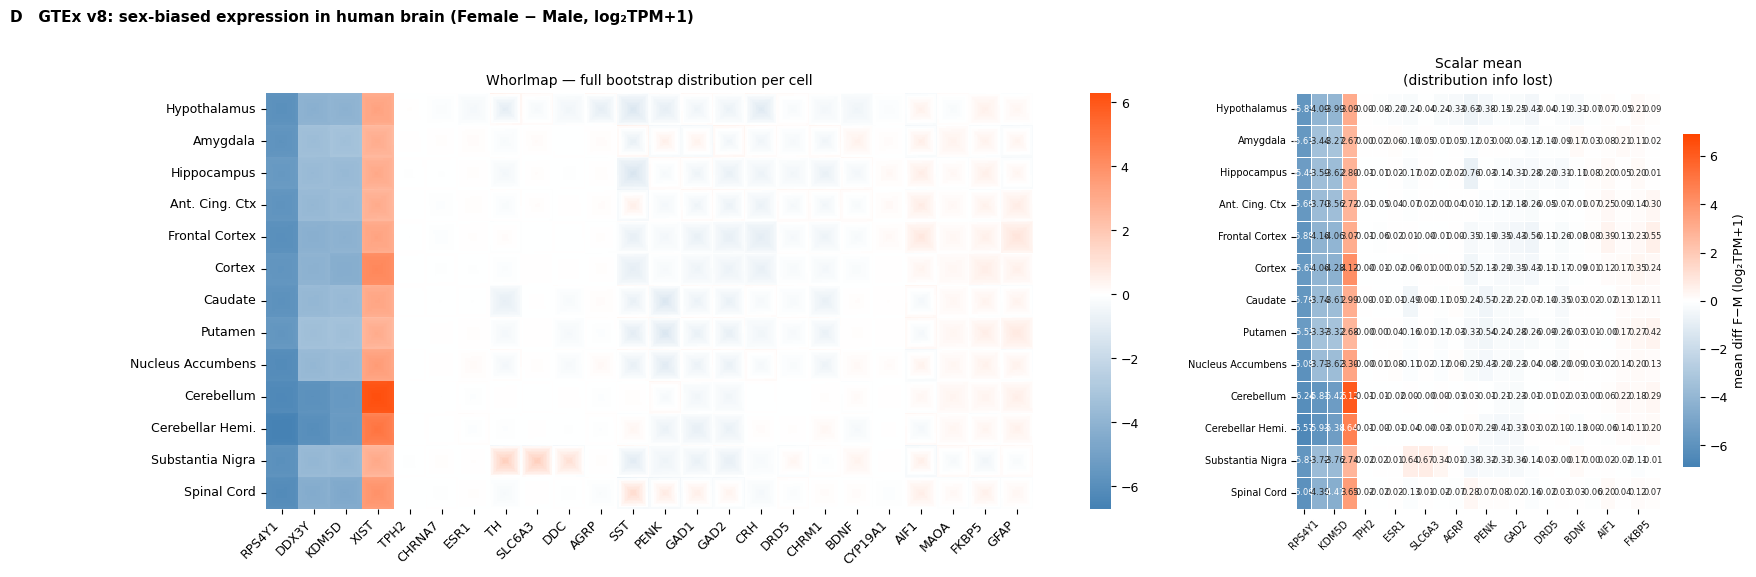

In [136]:
fig, (ax_whorl, ax_scalar) = plt.subplots(
    1, 2, figsize=(18, 5.5),
    gridspec_kw={"width_ratios": [3, 1.2]}
)

_, mean_df = multi.whorlmap(
    cmap=CMAP, chop_tail=2.5,
    title="Whorlmap — full bootstrap distribution per cell",
    ax=ax_whorl,
)
ax_whorl.set_aspect('equal')

vabs = float(mean_df.abs().max().max()) * 1.05
sns.heatmap(
    mean_df, ax=ax_scalar,
    cmap=CMAP, center=0, vmin=-vabs, vmax=vabs,
    annot=True, fmt=".2f",
    linewidths=0.4, linecolor="white",
    annot_kws={"fontsize": 6},
    cbar_kws={"label": "mean diff F−M (log₂TPM+1)", "shrink": 0.8},
)
ax_scalar.set_title("Scalar mean\n(distribution info lost)", fontsize=10)
ax_scalar.tick_params(axis="x", rotation=45, labelsize=7)
ax_scalar.tick_params(axis="y", rotation=0,  labelsize=7)

plt.suptitle(
    "D   GTEx v8: sex-biased expression in human brain (Female − Male, log₂TPM+1)",
    fontsize=11, fontweight="bold", x=0.02, ha="left", y=1.01,
)
plt.tight_layout()
fig.savefig(IMAGES / 'panel_d_gtex.svg', bbox_inches='tight')
fig.savefig(IMAGES / 'panel_d_gtex.png', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:


# Load pre-extracted data (avoids re-streaming the 2 GB TPM file)
with open("gtex_data/gene_expr.pkl", "rb") as f:
    gene_expr = pickle.load(f)
sample_meta = pd.read_csv("gtex_data/sample_meta.csv", index_col=0)

region_order = list(BRAIN_REGIONS.keys())

dabest_grid_right = []
for region in region_order:
    row = []
    for gene in RIGHT_GENES:
        gd = gene_expr[gene]
        mask  = sample_meta["region"] == region
        sids  = sample_meta.index[mask]
        recs  = [{"expr": gd[s], "sex": sample_meta.loc[s, "sex"]}
                 for s in sids if s in gd]
        df    = pd.DataFrame(recs)
        dobj  = dabest.load(df, x="sex", y="expr", idx=("Male", "Female"))
        row.append(dobj)
    dabest_grid_right.append(row)
    print(f"  built row: {region}", flush=True)

multi = combine(dabest_grid_right, RIGHT_GENES, row_labels=region_order, effect_size="mean_diff")
print(multi)

  built row: Hypothalamus
  built row: Amygdala
  built row: Hippocampus
  built row: Ant. Cing. Ctx
  built row: Frontal Cortex
  built row: Cortex
  built row: Caudate
  built row: Putamen
  built row: Nucleus Accumbens
  built row: Cerebellum
  built row: Cerebellar Hemi.
  built row: Substantia Nigra
  built row: Spinal Cord


/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
/Users/sangyuxu/Documents/GitHub/DABEST-python/dabest/_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result sho

In [ ]:
fig, (ax_whorl, ax_scalar) = plt.subplots(
    1, 2, figsize=(18, 5.5),
    gridspec_kw={"width_ratios": [3, 1.2]}
)

_, mean_df = multi.whorlmap(
    cmap=CMAP, chop_tail=2.5,
    title="Whorlmap — full bootstrap distribution per cell",
    ax=ax_whorl,
)
ax_whorl.set_aspect('equal')

vabs = float(mean_df.abs().max().max()) * 1.05
sns.heatmap(
    mean_df, ax=ax_scalar,
    cmap=CMAP, center=0, vmin=-vabs, vmax=vabs,
    annot=True, fmt=".2f",
    linewidths=0.4, linecolor="white",
    annot_kws={"fontsize": 6},
    cbar_kws={"label": "mean diff F−M (log₂TPM+1)", "shrink": 0.8},
)
ax_scalar.set_title("Scalar mean\n(distribution info lost)", fontsize=10)
ax_scalar.tick_params(axis="x", rotation=45, labelsize=7)
ax_scalar.tick_params(axis="y", rotation=0,  labelsize=7)

plt.suptitle(
    "D   GTEx v8: sex-biased expression in human brain (Female − Male, log₂TPM+1)",
    fontsize=11, fontweight="bold", x=0.02, ha="left", y=1.01,
)
plt.tight_layout()
fig.savefig(IMAGES / 'panel_d_gtex.svg', bbox_inches='tight')
fig.savefig(IMAGES / 'panel_d_gtex.png', dpi=600, bbox_inches='tight')
plt.show()
